# 02 — Exploratory Data Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from itertools import combinations
import scipy.stats as ss
from scipy.stats import  skew
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
pio.renderers.default = 'colab'
%matplotlib inline

COLORS = ['#26577C', '#E55604', '#CDC2AE', 'orange', '#867070']

In [2]:
df = pd.read_csv('../data/processed_data.csv')
print('Shape:', df.shape)
df.head()

Shape: (7032, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,0,DSL,0,1,0,0,0,0,Month-to-month,1,Electronic check,29.85,29.85,0
1,1,0,0,0,34,1,0,DSL,1,0,1,0,0,0,One year,0,Mailed check,56.95,1889.50,0
2,1,0,0,0,2,1,0,DSL,1,1,0,0,0,0,Month-to-month,1,Mailed check,53.85,108.15,1
3,1,0,0,0,45,0,0,DSL,1,0,1,1,0,0,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,0,0,0,0,2,1,0,Fiber optic,0,0,0,0,0,0,Month-to-month,1,Electronic check,70.70,151.65,1


## 1. Churn Distribution

In [3]:
df_churn = df['Churn'].value_counts().reset_index()
df_churn.columns = ['Churn', 'Count']
df_churn['Label'] = df_churn['Churn'].map({1: 'Churn', 0: 'No Churn'})

fig = go.Figure(data=[go.Pie(
    labels=df_churn['Label'],
    values=df_churn['Count'],
    hole=0.4,
    marker=dict(colors=[COLORS[0], COLORS[1]])
)])
fig.update_layout(
    title={'text': 'Customer Churn Distribution', 'x': 0.5},
    height=450,
    font=dict(size=14),
    template='plotly_white'
)
fig.show()

## 2. Numerical Feature Distributions

In [4]:
def num_viz(df, var):
    """Histogram with box marginal, split by churn status."""
    skew_val = round(skew(df[var], bias=False), 3)
    churn_label = df['Churn'].map({1: 'Churn', 0: 'No Churn'})
    fig = px.histogram(
        df.assign(Churn_Label=churn_label),
        x=var,
        marginal='box',
        color='Churn_Label',
        color_discrete_map={'No Churn': COLORS[0], 'Churn': COLORS[1]},
        title=f'{var}  |  Skewness: {skew_val}',
        template='plotly_white'
    ).update_layout(height=360, width=900, title_x=0.5)
    return fig

In [5]:
num_viz(df, 'tenure').show()

In [6]:
num_viz(df, 'MonthlyCharges').show()

In [7]:
num_viz(df, 'TotalCharges').show()

## 3. MonthlyCharges vs TotalCharges Scatter

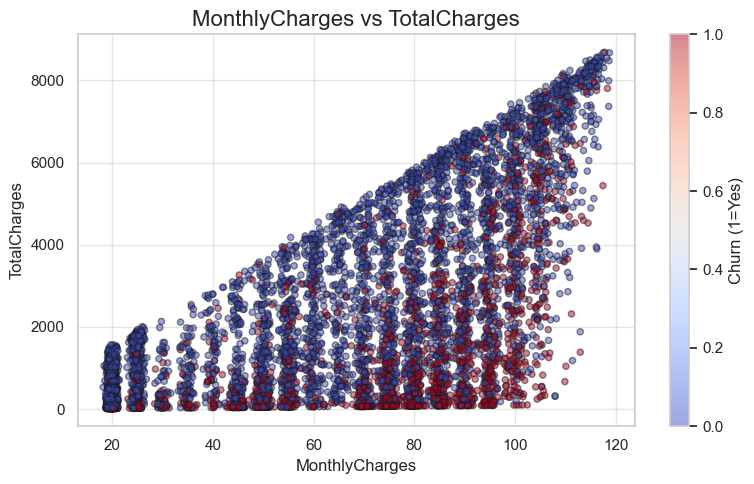

In [8]:
plt.figure(figsize=(8, 5))
plt.scatter(
    df['MonthlyCharges'], df['TotalCharges'],
    c=df['Churn'], cmap='coolwarm', edgecolors='k', alpha=0.5, s=20
)
plt.colorbar(label='Churn (1=Yes)')
plt.title('MonthlyCharges vs TotalCharges', fontsize=16)
plt.xlabel('MonthlyCharges')
plt.ylabel('TotalCharges')
plt.tight_layout()
plt.show()

## 4. Tenure Bins vs Charges

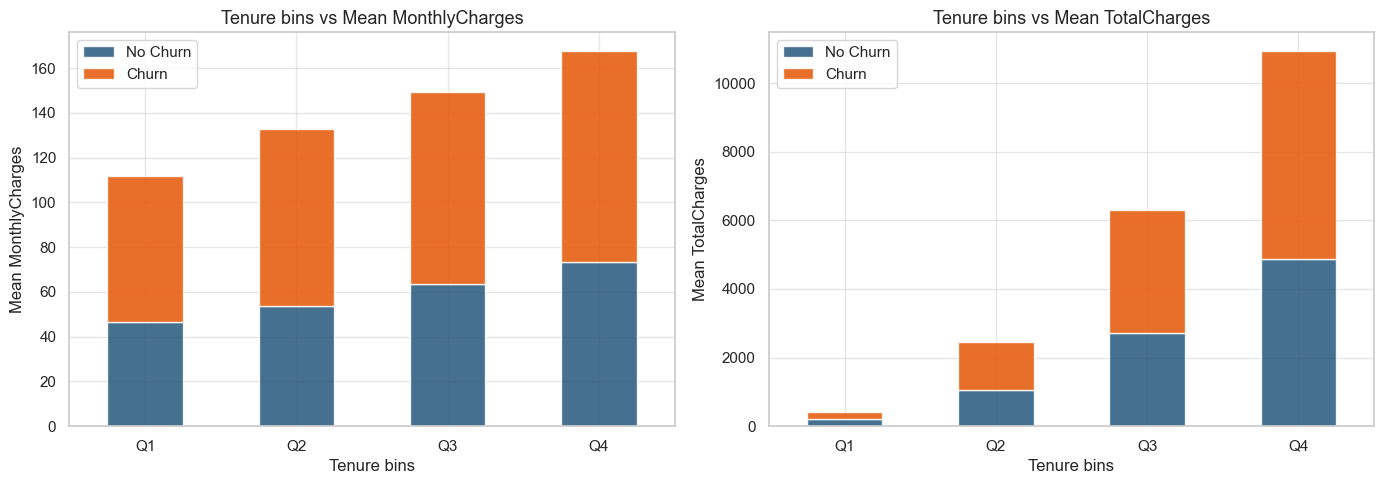

In [9]:
# Create bins only for visualization — NOT saved to the dataframe used for modeling
df_plot = df.copy()
df_plot['tenure_bins'] = pd.qcut(df_plot['tenure'].sort_values(), q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

churn_mask = df_plot['Churn'] == 1
no_churn_mask = df_plot['Churn'] == 0

def bar_2d(df, x_col, y_col, title, xlabel, ylabel):
    no_churn_mean = df[no_churn_mask].groupby(x_col)[y_col].mean()
    churn_mean    = df[churn_mask].groupby(x_col)[y_col].mean()
    pd.DataFrame({'No Churn': no_churn_mean, 'Churn': churn_mean}).plot(
        kind='bar', stacked=True, color=[COLORS[0], COLORS[1]], alpha=0.85, ax=plt.gca()
    )
    plt.title(title, fontsize=13)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=0)
    plt.legend()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plt.sca(axes[0])
bar_2d(df_plot, 'tenure_bins', 'MonthlyCharges', 'Tenure bins vs Mean MonthlyCharges', 'Tenure bins', 'Mean MonthlyCharges')
plt.sca(axes[1])
bar_2d(df_plot, 'tenure_bins', 'TotalCharges', 'Tenure bins vs Mean TotalCharges', 'Tenure bins', 'Mean TotalCharges')
plt.tight_layout()
plt.show()

## 5. Categorical Features vs Churn

In [10]:
# Payment method distribution
labels = df['PaymentMethod'].value_counts().index
values = df['PaymentMethod'].value_counts().values

fig = go.Figure(data=[go.Pie(
    labels=labels, values=values, hole=0.3,
    marker=dict(colors=COLORS[:4])
)])
fig.update_layout(title_text='Payment Method Distribution', title_x=0.5, template='plotly_white')
fig.show()

In [11]:
# Payment method vs churn
color_map = {
    'Electronic check':        COLORS[0],
    'Mailed check':            COLORS[1],
    'Bank transfer (automatic)': COLORS[2],
    'Credit card (automatic)': 'orange'
}
churn_label = df['Churn'].map({1: 'Churn', 0: 'No Churn'})
fig = px.histogram(
    df.assign(Churn_Label=churn_label),
    x='Churn_Label', color='PaymentMethod',
    title='Payment Method vs Churn',
    color_discrete_map=color_map,
    template='plotly_white'
)
fig.update_layout(width=700, height=450, bargap=0.1)
fig.show()

In [12]:
# Contract type vs churn
fig = px.histogram(
    df.assign(Churn_Label=churn_label),
    x='Churn_Label', color='Contract',
    title='Contract Type vs Churn',
    template='plotly_white'
)
fig.update_layout(width=700, height=450, bargap=0.1)
fig.show()

In [13]:
# Internet service vs churn
fig = px.histogram(
    df.assign(Churn_Label=churn_label),
    x='Churn_Label', color='InternetService',
    title='Internet Service vs Churn',
    template='plotly_white'
)
fig.update_layout(width=700, height=450, bargap=0.1)
fig.show()

## 6. Cramér's V — Categorical Correlation Matrix

In [14]:
def cramers_v(confusion_matrix):
    """Cramér's V: measures association between two categorical variables."""
    chi2 = ss.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    return np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))

def get_corr_mat(df_subset):
    columns = df_subset.columns
    dm = pd.DataFrame(index=columns, columns=columns)
    for var1, var2 in combinations(columns, 2):
        ct = pd.crosstab(df_subset[var1], df_subset[var2], margins=False)
        v = cramers_v(ct.values)
        dm.loc[var1, var2] = v
        dm.loc[var2, var1] = v
    dm.fillna(1, inplace=True)
    return dm.astype(float)

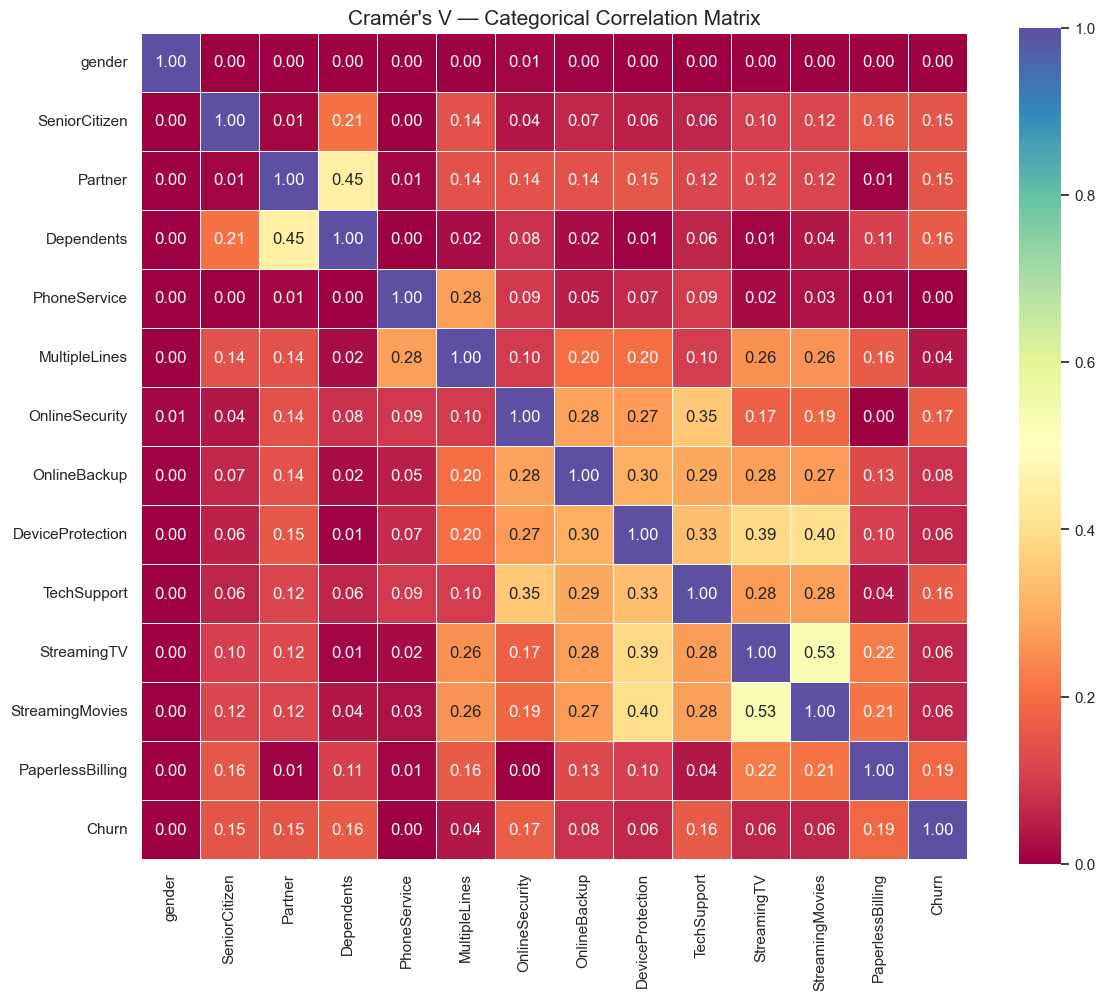

In [15]:
# Select categorical-like columns for correlation
cat_cols = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'PaperlessBilling', 'Churn'
]

cat_corr = get_corr_mat(df[cat_cols])

plt.figure(figsize=(12, 10))
sns.heatmap(cat_corr, annot=True, fmt='.2f', cmap='Spectral', square=True, linewidths=0.5)
plt.title('Cramér\'s V — Categorical Correlation Matrix', fontsize=15)
plt.tight_layout()
plt.show()

## 7. Numeric Correlation Heatmap

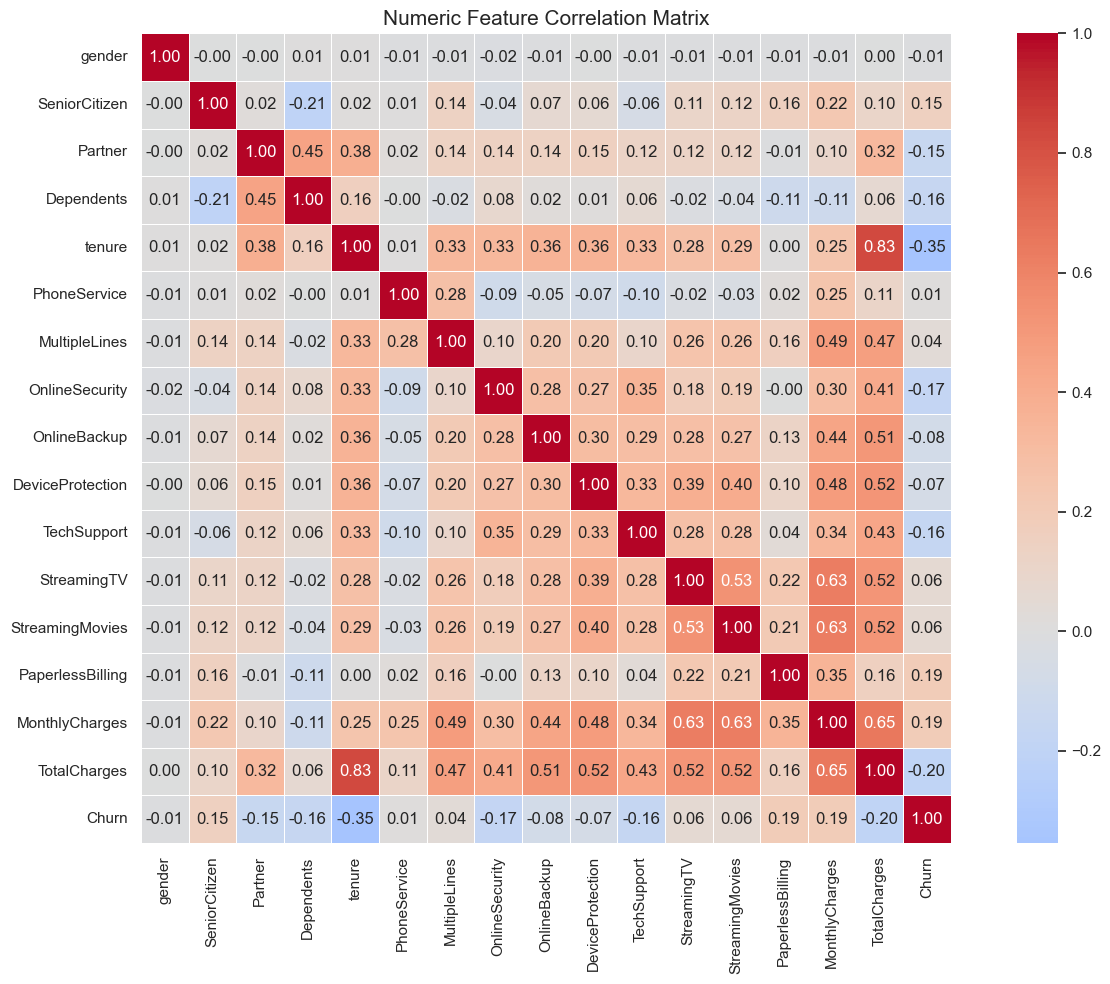

In [16]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(14, 10))
sns.heatmap(
    df[numeric_cols].corr(),
    annot=True, fmt='.2f', cmap='coolwarm',
    center=0, linewidths=0.5, square=True
)
plt.title('Numeric Feature Correlation Matrix', fontsize=15)
plt.tight_layout()
plt.show()

## 8. Key Insights Summary

| Factor            | Increases Churn  | Decreases Churn  |
|-------------------|------------------|------------------|
| Contract          | Month-to-month   | Two-year         |
| Internet service  | Fiber optic      | No internet      |
| Payment method    | Electronic check | Auto credit card |
| Tenure            | Short            | Long             |
| Security services | None enabled     | All enabled      |
| Monthly charges   | High             | Low              |